## Imports & Configuration

In [2]:
from pathlib import Path
import json
import sys

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, log_loss

# Allow this script to run from the repo root, DataPrepper/, or Colab.
if "__file__" in globals():
    script_dir = Path(__file__).resolve().parent
    REPO_ROOT = script_dir.parent if script_dir.name == "DataPrepper" else script_dir
else:
    REPO_ROOT = Path.cwd()
for path_candidate in (REPO_ROOT, Path.cwd()):
    if str(path_candidate) not in sys.path:
        sys.path.insert(0, str(path_candidate))

from core.features import (  # noqa: E402
    EUR_NEWS_COUNTRIES,
    FEATURE_COLUMNS_V7,
    USD_NEWS_COUNTRIES,
    engineer_25_features,
    generate_barrier_labels,
    join_timeframes,
    labels_to_lgb_classes,
)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Build the Dataset (v6 — Hardened)

In [4]:
DATA_DIR = Path("/content/drive/MyDrive/ForexData")
OUTPUT_DIR = Path("/content/drive/MyDrive/ForexData/model_v7")
if not DATA_DIR.exists():
    DATA_DIR = REPO_ROOT / "DataPrepper"
    OUTPUT_DIR = REPO_ROOT / "model"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

K_CANDLES = 12
ATR_SL_MULTIPLIER = 1.5
CONFIDENCE_THRESHOLD = 0.55
SPREAD_PIPS = 0.5
SLIPPAGE_PIPS = 0.2
MAX_OPEN_TRADES = 2

LGB_PARAMS = {
    "objective": "multiclass",
    "num_class": 3,
    "metric": "multi_logloss",
    "learning_rate": 0.01,
    "num_leaves": 31,
    "max_depth": 6,
    "min_data_in_leaf": 50,
    "lambda_l1": 0.1,
    "lambda_l2": 1.0,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "feature_fraction": 0.7,
    "verbosity": -1,
    "random_state": 42,
    "deterministic": True,
    "num_threads": 1,
}

CLASS_NAMES = ["NO_TRADE", "LONG", "SHORT"]


def load_ohlcv(filename: Path) -> pd.DataFrame:
    df = pd.read_csv(filename)
    df["Date"] = df["Date"].astype(str)
    df["Datetime"] = pd.to_datetime(df["Date"] + " " + df["Timestamp"])
    df = df.set_index("Datetime").drop(columns=["Date", "Timestamp"])
    return df[["Open", "High", "Low", "Close", "Volume"]].sort_index()


def load_news(news_file: Path, price_index: pd.DatetimeIndex):
    if not news_file.exists():
        print(f"News file not found at {news_file}; using default 10000-minute news distances.")
        return [], []

    news_df = pd.read_csv(news_file)
    news_df["event_time"] = pd.to_datetime(news_df["event_time"], errors="coerce")
    news_df = news_df.dropna(subset=["event_time", "country"])

    if price_index.tz is None and getattr(news_df["event_time"].dt, "tz", None) is not None:
        news_df["event_time"] = news_df["event_time"].dt.tz_convert("UTC").dt.tz_localize(None)
    elif price_index.tz is not None and getattr(news_df["event_time"].dt, "tz", None) is None:
        news_df["event_time"] = news_df["event_time"].dt.tz_localize("UTC")

    us_news = news_df.loc[news_df["country"].isin(USD_NEWS_COUNTRIES), "event_time"].sort_values()
    eu_news = news_df.loc[news_df["country"].isin(EUR_NEWS_COUNTRIES), "event_time"].sort_values()
    return us_news, eu_news


def build_forex_dataset_v7():
    print("Step 1: Loading multi-timeframe data...")
    df_5m = load_ohlcv(DATA_DIR / "EURUSD_5mins.csv")
    df_1h = load_ohlcv(DATA_DIR / "EURUSD_1hr.csv")
    df_4h = load_ohlcv(DATA_DIR / "EURUSD_4hr.csv")

    us_news, eu_news = load_news(DATA_DIR / "historical_news (1).csv", df_5m.index)
    all_news = pd.concat([pd.Series(us_news), pd.Series(eu_news)]).dropna()
    if not all_news.empty:
        df_5m = df_5m[(df_5m.index >= all_news.min()) & (df_5m.index <= all_news.max())]

    print("Step 2: Joining timeframes with closed-candle HTF alignment...")
    df = join_timeframes(df_5m, df_1h, df_4h)

    print("Step 3: Engineering shared v7 features...")
    df = engineer_25_features(df, us_news=us_news, eu_news=eu_news)
    missing = [col for col in FEATURE_COLUMNS_V7 if col not in df.columns]
    assert not missing, f"Missing v7 features: {missing}"
    assert len(FEATURE_COLUMNS_V7) == 25, f"Expected 25 features, got {len(FEATURE_COLUMNS_V7)}"

    print("Step 4: Creating barrier labels...")
    df["Barrier_Label"] = generate_barrier_labels(df, K_CANDLES, ATR_SL_MULTIPLIER)
    df = df.dropna(subset=FEATURE_COLUMNS_V7 + ["Barrier_Label", "ATR_5m_14"])
    df["Target_Class"] = labels_to_lgb_classes(df["Barrier_Label"])

    distribution = df["Target_Class"].value_counts(normalize=True).sort_index()
    print("Label distribution:")
    for class_id, share in distribution.items():
        print(f"  {class_id} ({CLASS_NAMES[class_id]}): {share:.2%}")

    return df, df[FEATURE_COLUMNS_V7], df["Target_Class"]



## Walk-Forward Core (De-duplicated)

In [5]:
def generate_walk_forward_predictions(X, y_pips):
    """
    Core Walk-Forward Loop: Trains models sequentially and generates 
    clean Out-Of-Sample (OOS) predictions for the entire dataset.
    """
    print("--- Generating Walk-Forward OOS Predictions ---")
    total_samples = len(X)
    n_splits = 5
    purge_candles = K_CANDLES

    initial_train_idx = int(total_samples * 0.7)
    val_step = int((total_samples - initial_train_idx) / n_splits)
    
    all_oos = []
    fold_metrics = []
    
    for fold in range(n_splits):
        train_end = initial_train_idx + (fold * val_step)
        val_start = train_end + purge_candles
        val_end = min(val_start + val_step, total_samples)
        
        if val_start >= total_samples: break

        X_train, y_train = X.iloc[:train_end], y_pips.iloc[:train_end]
        X_val, y_val = X.iloc[val_start:val_end], y_pips.iloc[val_start:val_end]
        val_dates = X.index[val_start:val_end]

        train_data = lgb.Dataset(X_train, label=y_train)
        val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

        model = lgb.train(
            LGB_PARAMS, train_data, num_boost_round=1500,
            valid_sets=[val_data],
            callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
        )
        
        preds = model.predict(X_val, num_iteration=model.best_iteration)
        
        # Fold diagnostics
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        ic = stats.spearmanr(preds, y_val).correlation
        fold_metrics.append({'Fold': fold + 1, 'RMSE': rmse, 'IC': ic})
        
        all_oos.append(pd.DataFrame({
            'Predicted_Pips': preds,
            'Actual_Pips': y_val.values
        }, index=val_dates))
        
        print(f"Fold {fold+1} trained. RMSE: {rmse:.3f} | IC: {ic:.4f}")

    oos_df = pd.concat(all_oos)
    return oos_df, pd.DataFrame(fold_metrics)

# 1. Generate the OOS baseline
oos_predictions, _ = generate_walk_forward_predictions(X, y)

NameError: name 'X' is not defined

## Threshold Optimization & Backtesting

In [7]:
def optimize_pip_threshold(oos_df, spread_pips=0.5):
    print("\n--- Sweeping Pip Thresholds (OOS) ---")
    thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.7, 1.0, 1.5]
    results = []

    for t in thresholds:
        df_sim = oos_df.copy()
        df_sim['Signal'] = 0
        df_sim.loc[df_sim['Predicted_Pips'] >= t, 'Signal'] = 1
        df_sim.loc[df_sim['Predicted_Pips'] <= -t, 'Signal'] = -1

        trades = df_sim[df_sim['Signal'] != 0].copy()
        if len(trades) == 0: continue

        trades['Net_Pips'] = (trades['Signal'] * trades['Actual_Pips']) - spread_pips
        win_rate = len(trades[trades['Net_Pips'] > 0]) / len(trades)
        net_profit = trades['Net_Pips'].sum()
        sharpe = trades['Net_Pips'].mean() / (trades['Net_Pips'].std() + 1e-8)

        results.append({
            'Threshold': t, 'Trades': len(trades),
            'Win_Rate': f"{win_rate:.2%}", 'Net_Pips': round(net_profit, 1),
            'Sharpe': round(sharpe, 4), 'Avg_PnL': round(trades['Net_Pips'].mean(), 2)
        })

    metrics_df = pd.DataFrame(results)
    print(metrics_df.to_string(index=False))
    return metrics_df

# 2. Find the optimal entry threshold
sweep_results = optimize_pip_threshold(oos_predictions, spread_pips=0.5)

# For this example, let's select a fixed threshold based on average performance
OPTIMAL_THRESHOLD = 0.3


--- Sweeping Pip Thresholds (OOS) ---
 Threshold  Trades Win_Rate  Net_Pips  Sharpe  Avg_PnL
       0.1    2536   52.29%    -762.0 -0.0265    -0.30
       0.2    1519   52.34%    -329.7 -0.0192    -0.22
       0.3     382   53.93%     316.1  0.0631     0.83
       0.4     184   54.89%     308.4  0.1225     1.68
       0.5      79   58.23%     126.3  0.0989     1.60
       0.7      17   41.18%     -50.6 -0.2972    -2.98
       1.0       9   44.44%     -47.0 -0.4380    -5.22
       1.5       2   50.00%     -11.5 -0.6304    -5.75



--- Realistic Non-Overlapping Backtest ---
Total Trades Taken: 382 (Overlap Blocked)
Win Rate (Post-Spread): 53.93%
Net Profit: 316.10 Pips


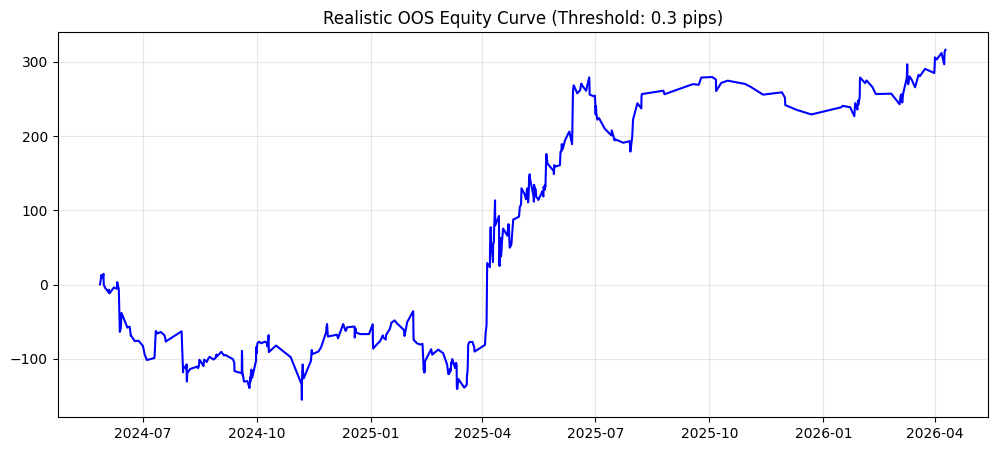

In [ ]:
def generate_walk_forward_predictions(X: pd.DataFrame, y: pd.Series, market_df: pd.DataFrame):
    print("\n--- Generating Walk-Forward OOS Predictions ---")
    total_samples = len(X)
    n_splits = 5
    purge_candles = K_CANDLES
    initial_train_idx = int(total_samples * 0.7)
    val_step = max(int((total_samples - initial_train_idx) / n_splits), 1)

    all_oos = []
    fold_metrics = []

    for fold in range(n_splits):
        train_end = initial_train_idx + (fold * val_step)
        val_start = train_end + purge_candles
        val_end = min(val_start + val_step, total_samples)
        if val_start >= total_samples:
            break

        X_train, y_train = X.iloc[:train_end], y.iloc[:train_end]
        X_val, y_val = X.iloc[val_start:val_end], y.iloc[val_start:val_end]
        val_dates = X.index[val_start:val_end]

        train_data = lgb.Dataset(X_train, label=y_train)
        val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)
        model = lgb.train(
            LGB_PARAMS,
            train_data,
            num_boost_round=1500,
            valid_sets=[val_data],
            callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
        )

        probs = model.predict(X_val, num_iteration=model.best_iteration)
        pred_class = np.argmax(probs, axis=1)

        fold_log_loss = log_loss(y_val, probs, labels=[0, 1, 2])
        fold_accuracy = accuracy_score(y_val, pred_class)
        fold_macro_f1 = f1_score(y_val, pred_class, labels=[0, 1, 2], average="macro")
        fold_metrics.append(
            {
                "Fold": fold + 1,
                "LogLoss": fold_log_loss,
                "Accuracy": fold_accuracy,
                "Macro_F1": fold_macro_f1,
            }
        )

        fold_oos = market_df.loc[val_dates, ["Open", "High", "Low", "Close", "ATR_5m_14", "Barrier_Label"]].copy()
        fold_oos["Actual_Class"] = y_val.values
        fold_oos["P_NO_TRADE"] = probs[:, 0]
        fold_oos["P_LONG"] = probs[:, 1]
        fold_oos["P_SHORT"] = probs[:, 2]
        fold_oos["Pred_Class"] = pred_class
        all_oos.append(fold_oos)

        print(
            f"Fold {fold + 1}: logloss={fold_log_loss:.4f} | "
            f"accuracy={fold_accuracy:.2%} | macro_f1={fold_macro_f1:.4f}"
        )

    oos_df = pd.concat(all_oos).sort_index()
    metrics_df = pd.DataFrame(fold_metrics)

    print("\nClassification report (OOS):")
    print(classification_report(oos_df["Actual_Class"], oos_df["Pred_Class"], target_names=CLASS_NAMES))
    print("Confusion matrix (rows=actual, cols=predicted):")
    print(confusion_matrix(oos_df["Actual_Class"], oos_df["Pred_Class"], labels=[0, 1, 2]))

    return oos_df, metrics_df

In [ ]:
def signal_from_probs(row, confidence_threshold: float) -> int:
    if row["P_LONG"] > confidence_threshold and row["P_LONG"] >= row["P_SHORT"]:
        return 1
    if row["P_SHORT"] > confidence_threshold:
        return -1
    return 0


def simulate_barrier_exit(market_df: pd.DataFrame, entry_time, signal: int):
    entry_loc = market_df.index.get_loc(entry_time)
    entry_price = market_df["Close"].iloc[entry_loc]
    atr = market_df["ATR_5m_14"].iloc[entry_loc]
    distance = atr * ATR_SL_MULTIPLIER

    if signal == 1:
        tp = entry_price + distance
        sl = entry_price - distance
    else:
        tp = entry_price - distance
        sl = entry_price + distance

    max_exit = min(entry_loc + K_CANDLES, len(market_df) - 1)
    exit_loc = max_exit
    exit_reason = "TIME"
    gross_pips = 0.0

    for i in range(entry_loc + 1, max_exit + 1):
        high = market_df["High"].iloc[i]
        low = market_df["Low"].iloc[i]
        if signal == 1:
            tp_hit = high >= tp
            sl_hit = low <= sl
        else:
            tp_hit = low <= tp
            sl_hit = high >= sl

        exit_loc = i
        if tp_hit and sl_hit:
            exit_reason = "AMBIGUOUS_SL"
            gross_pips = -distance * 10000
            break
        if tp_hit:
            exit_reason = "TP"
            gross_pips = distance * 10000
            break
        if sl_hit:
            exit_reason = "SL"
            gross_pips = -distance * 10000
            break
    else:
        exit_price = market_df["Close"].iloc[exit_loc]
        gross_pips = signal * (exit_price - entry_price) * 10000

    net_pips = gross_pips - SPREAD_PIPS - SLIPPAGE_PIPS
    return market_df.index[exit_loc], exit_reason, gross_pips, net_pips


def run_realistic_backtest(
    oos_df: pd.DataFrame,
    market_df: pd.DataFrame,
    confidence_threshold: float = CONFIDENCE_THRESHOLD,
    max_open_trades: int = MAX_OPEN_TRADES,
):
    print("\n--- Realistic Barrier Backtest ---")
    open_until = []
    trade_records = []

    for current_time, row in oos_df.iterrows():
        open_until = [exit_time for exit_time in open_until if exit_time > current_time]
        if len(open_until) >= max_open_trades:
            continue

        signal = signal_from_probs(row, confidence_threshold)
        if signal == 0:
            continue

        exit_time, exit_reason, gross_pips, net_pips = simulate_barrier_exit(market_df, current_time, signal)
        open_until.append(exit_time)
        trade_records.append(
            {
                "Entry_Time": current_time,
                "Exit_Time": exit_time,
                "Signal": signal,
                "Exit_Reason": exit_reason,
                "Gross_Pips": gross_pips,
                "Net_Pips": net_pips,
                "P_LONG": row["P_LONG"],
                "P_SHORT": row["P_SHORT"],
            }
        )

    trades_df = pd.DataFrame(trade_records)
    if trades_df.empty:
        print("No trades taken.")
        return trades_df

    trades_df = trades_df.set_index("Entry_Time")
    trades_df["Cumulative_Pips"] = trades_df["Net_Pips"].cumsum()

    win_rate = (trades_df["Net_Pips"] > 0).mean()
    net_profit = trades_df["Net_Pips"].sum()
    avg_pnl = trades_df["Net_Pips"].mean()
    sharpe = avg_pnl / (trades_df["Net_Pips"].std() + 1e-8)

    print(f"Total Trades: {len(trades_df):,}")
    print(f"Win Rate: {win_rate:.2%}")
    print(f"Net Profit: {net_profit:.2f} pips")
    print(f"Avg PnL: {avg_pnl:.2f} pips | Sharpe-like: {sharpe:.4f}")
    print(trades_df["Exit_Reason"].value_counts().to_string())

    plt.figure(figsize=(12, 5))
    plt.plot(trades_df.index, trades_df["Cumulative_Pips"], color="blue")
    plt.title(f"V7 OOS Equity Curve (confidence >= {confidence_threshold:.2f})")
    plt.grid(True, alpha=0.3)
    plt.show()

    return trades_df


## Train Final Live Model & Export

In [6]:
def train_final_model(X: pd.DataFrame, y: pd.Series):
    print("\n--- Training Final Production Classifier ---")
    train_data = lgb.Dataset(X, label=y)
    model = lgb.train(LGB_PARAMS, train_data, num_boost_round=800)
    print("Final model trained successfully.")
    return model


master_df, X, y = build_forex_dataset_v7()
oos_predictions, fold_metrics = generate_walk_forward_predictions(X, y, master_df)
realistic_trades = run_realistic_backtest(oos_predictions, master_df)
production_model = train_final_model(X, y)

joblib.dump(production_model, OUTPUT_DIR / "forex_model_v7.pkl")
joblib.dump(FEATURE_COLUMNS_V7, OUTPUT_DIR / "feature_names_v7.pkl")

config = {
    "model_type": "barrier_v7",
    "model_version": "v7",
    "k_candles": K_CANDLES,
    "atr_sl_multiplier": ATR_SL_MULTIPLIER,
    "confidence_threshold": CONFIDENCE_THRESHOLD,
    "risk_pct": 0.02,
    "max_risk_pct": 0.10,
    "max_daily_drawdown": 0.20,
    "max_open_trades": MAX_OPEN_TRADES,
    "max_position_size": 100000,
    "slippage_pips": SLIPPAGE_PIPS,
    "spread_pips": SPREAD_PIPS,
    "use_time_exit": False,
}
with open(OUTPUT_DIR / "model_config.json", "w") as f:
    json.dump(config, f, indent=4)

print(f"Exported v7 model artifacts to: {OUTPUT_DIR}")

Step 1: Loading multi-timeframe data...
Step 2: Joining timeframes with closed-candle HTF alignment...
Step 3: Engineering shared v7 features...
Step 4: Creating barrier labels...
Label distribution:
  0 (NO_TRADE): 14.49%
  1 (LONG): 42.75%
  2 (SHORT): 42.75%


TypeError: generate_walk_forward_predictions() takes 2 positional arguments but 3 were given